# Moment Tensors: Decomposition and Catalog Reading

 > **Colab note:** This notebook is designed to run on **Google Colab**.  The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-geophysics-edu/ess-412-512-intro2seismology/blob/main/notebooks/07a_Moment_Tensor_Practice.ipynb)

**Learning objectives:**
By the end of this notebook you should be able to:

1. Explain why moment tensors are **symmetric** and **diagonalizable** (6 independent components)
2. Split **M** into **ISO + DEV**; then **DEV → DC + CLVD** using eigenvalues
3. Use the **δ diagnostic** to quantify non-DC content
4. Visualize **P-wave radiation patterns** for DC, CLVD, and ISO sources
5. **Read a USGS moment tensor** (components + derived %DC-style diagnostics)
6. Classify source processes by their **ISO/DC/CLVD** content

**Key concepts:**
- **Symmetry**: $\mathbf{M} = \mathbf{M}^T$ → 6 independent components
- **ISO/DEV split**: $\mathbf{M}_\text{ISO} = \frac{\text{tr}(\mathbf{M})}{3}\mathbf{I}$, $\mathbf{M}_\text{DEV} = \mathbf{M} - \mathbf{M}_\text{ISO}$
- **DC eigenvalues**: $(+M_0,\ 0,\ -M_0)$ → shear faulting
- **δ diagnostic**: $\delta = \varphi_2 / \max(|\varphi_1|, |\varphi_3|)$; $\delta=0$ pure DC, $|\delta|=0.5$ pure CLVD

**Prerequisites:** Module 6 (earthquake location), linear algebra (eigenvalues/eigenvectors)

**Reference:** Shearer (2009), *Introduction to Seismology*, Chapter 9.2

**Notebook Outline:**
- [Part A: Symmetry and Eigenframes](#part-a-symmetry-and-eigenframes)
- [Part B: ISO/DEV Split](#part-b-isodev-split)
- [Part C: DEV → DC + CLVD Decomposition](#part-c-dev--dc--clvd-decomposition)
- [Part D: P-wave Radiation Proxy](#part-d-p-wave-radiation-proxy)
- [Part E: Reading a USGS Moment Tensor](#part-e-reading-a-usgs-moment-tensor)
- [Exercises](#exercises)
- [Summary and Connections](#summary-and-connections)

> **Prediction prompt:** Before running any code, predict: a pure explosion has eigenvalues $(1, 1, 1)$. How many nodal planes does its P-wave radiation pattern have?

---

In [1]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'requests': 'requests'
}

# Optional packages
optional_packages = {
    'obspy': 'obspy'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

for package, pip_name in optional_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed (optional)")
    except ImportError:
        print(f"⊘ {package} not found (optional — beachball plots will be skipped)")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

Running in local environment
✓ numpy is already installed
✓ matplotlib is already installed
✓ requests is already installed
✓ obspy is already installed (optional)

✓ All required packages are installed!


## Setup: Imports and plotting defaults

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import requests

# Optional: ObsPy beachball plotting
try:
    from obspy.imaging.beachball import beachball
    _HAS_OBSPY = True
except Exception:
    _HAS_OBSPY = False

# Reproducibility
np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

# Plotting defaults (consistent with other course notebooks)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print("✓ Imports and plotting defaults loaded")

✓ Imports and plotting defaults loaded


---

## Part A: Symmetry and Eigenframes

### A1. Why symmetric?

The moment tensor must be **symmetric** ($\mathbf{M} = \mathbf{M}^T$) because conservation of angular momentum forbids net torque from the equivalent force system. A general 3×3 matrix has 9 components, but symmetry reduces this to **6 independent** components.

> **Prediction prompt:** If we start with an arbitrary 3×3 matrix A and interpret it as a "moment tensor," what is physically wrong? How many independent parameters does a symmetric 3×3 matrix have?

In [3]:
# Symmetrize an arbitrary matrix to make a valid moment tensor
def symmetrize(A):
    """Force a matrix to be symmetric: M = (A + A^T) / 2"""
    return 0.5 * (A + A.T)

# Start with a random 3x3 matrix
A = np.random.randn(3, 3)
M = symmetrize(A)

print("A (raw, non-symmetric):")
print(A)
print(f"\nM (symmetrized):")
print(M)
print(f"\nSymmetry check ||M - M^T|| = {np.linalg.norm(M - M.T):.2e}")
print(f"Number of independent components: {len(M[np.triu_indices(3)])}")

# Verify: upper triangle contains all independent info
print(f"\nUpper triangle values: {M[np.triu_indices(3)]}")

A (raw, non-symmetric):
[[ 0.4967 -0.1383  0.6477]
 [ 1.523  -0.2342 -0.2341]
 [ 1.5792  0.7674 -0.4695]]

M (symmetrized):
[[ 0.4967  0.6924  1.1135]
 [ 0.6924 -0.2342  0.2666]
 [ 1.1135  0.2666 -0.4695]]

Symmetry check ||M - M^T|| = 0.00e+00
Number of independent components: 6

Upper triangle values: [ 0.4967  0.6924  1.1135 -0.2342  0.2666 -0.4695]


### A2. Eigen-decomposition (principal axes)

Because $\mathbf{M}$ is symmetric, it can always be diagonalized:

$$\mathbf{M} = \mathbf{V}\,\text{diag}(\lambda_1, \lambda_2, \lambda_3)\,\mathbf{V}^T$$

- **Eigenvectors** (columns of $\mathbf{V}$) = principal axes → **orientation**
- **Eigenvalues** ($\lambda_1 \geq \lambda_2 \geq \lambda_3$) → **source type**

> **Prediction prompt:** Why do we care about diagonalization? What does it separate?

In [4]:
# Eigen-decomposition of our symmetric moment tensor
vals, vecs = np.linalg.eigh(M)  # eigh is for symmetric matrices (guaranteed real eigenvalues)

# Sort eigenvalues in descending order (convention: λ1 ≥ λ2 ≥ λ3)
idx = np.argsort(vals)[::-1]
vals = vals[idx]
vecs = vecs[:, idx]

print("Eigenvalues (descending):", vals)
print(f"\nEigenvectors (columns of V):")
print(vecs)
print(f"\nOrthonormality check V^T V:")
print(vecs.T @ vecs)

# Verify reconstruction: M = V diag(λ) V^T
M_recon = vecs @ np.diag(vals) @ vecs.T
print(f"\nReconstruction error ||M - V Λ V^T|| = {np.linalg.norm(M - M_recon):.2e}")

Eigenvalues (descending): [ 1.5274 -0.5028 -1.2315]

Eigenvectors (columns of V):
[[ 0.7844 -0.205  -0.5854]
 [ 0.3823  0.903   0.196 ]
 [ 0.4884 -0.3775  0.7867]]

Orthonormality check V^T V:
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]

Reconstruction error ||M - V Λ V^T|| = 8.46e-16


---

## Part B: ISO/DEV Split

The moment tensor can be decomposed into two physically distinct parts:

$$\mathbf{M}_\text{ISO} = \frac{\text{tr}(\mathbf{M})}{3}\,\mathbf{I} \qquad \text{(volume change)}$$

$$\mathbf{M}_\text{DEV} = \mathbf{M} - \mathbf{M}_\text{ISO} \qquad \text{(shear + CLVD, with } \text{tr}(\mathbf{M}_\text{DEV}) = 0\text{)}$$

> **Prediction prompt:** If you add $c \cdot \mathbf{I}$ to a pure DC tensor, what changes qualitatively? Does the DC part change, or only the ISO part?

In [5]:
def iso_part(M):
    """Compute isotropic part: M_iso = (tr(M)/3) * I"""
    return (np.trace(M) / 3.0) * np.eye(3)

def dev_part(M):
    """Compute deviatoric part: M_dev = M - M_iso (trace = 0)"""
    return M - iso_part(M)

M_iso = iso_part(M)
M_dev = dev_part(M)

print("=== ISO/DEV Decomposition ===")
print(f"tr(M)     = {np.trace(M):.4f}")
print(f"tr(M_iso) = {np.trace(M_iso):.4f}  (should equal tr(M))")
print(f"tr(M_dev) = {np.trace(M_dev):.4e}  (should be ~0)")
print(f"\nM_iso:")
print(M_iso)
print(f"\nM_dev:")
print(M_dev)
print(f"\nReconstruction check ||M - (M_iso + M_dev)|| = {np.linalg.norm(M - (M_iso + M_dev)):.2e}")

=== ISO/DEV Decomposition ===
tr(M)     = -0.2069
tr(M_iso) = -0.2069  (should equal tr(M))
tr(M_dev) = -5.5511e-17  (should be ~0)

M_iso:
[[-0.069 -0.    -0.   ]
 [-0.    -0.069 -0.   ]
 [-0.    -0.    -0.069]]

M_dev:
[[ 0.5657  0.6924  1.1135]
 [ 0.6924 -0.1652  0.2666]
 [ 1.1135  0.2666 -0.4005]]

Reconstruction check ||M - (M_iso + M_dev)|| = 0.00e+00


---

## Part C: DEV → DC + CLVD Decomposition

This is the **key algorithm** of the lab. Given a moment tensor, we decompose it completely:

$$\mathbf{M} = \mathbf{M}_\text{ISO} + \mathbf{M}_\text{DC} + \mathbf{M}_\text{CLVD}$$

**Algorithm (in principal axes of $\mathbf{M}_\text{DEV}$):**
1. Compute $\mathbf{M}_\text{DEV}$
2. Eigen-decompose → $\varphi_1 \geq \varphi_2 \geq \varphi_3$ (sum = 0)
3. Best-fitting DC amplitude: $M_0^\text{DC} = (\varphi_1 - \varphi_3)/2$
4. DC diagonal: $\text{diag}(M_0^\text{DC},\ 0,\ -M_0^\text{DC})$
5. CLVD diagonal: $\text{diag}(\varphi_2/2,\ -\varphi_2,\ \varphi_2/2)$
6. Rotate both back with eigenvectors

**δ diagnostic:** $\delta = \varphi_2 / \max(|\varphi_1|, |\varphi_3|)$

> **Prediction prompt:** What happens when $\varphi_2 = 0$? What does $\delta = 0$ mean physically?

In [6]:
def eig_sorted_sym(M):
    """Eigen-decompose a symmetric matrix, return eigenvalues sorted descending."""
    vals, vecs = np.linalg.eigh(M)
    idx = np.argsort(vals)[::-1]
    return vals[idx], vecs[:, idx]

def dc_clvd_decomposition(M):
    """
    Full moment tensor decomposition: M = ISO + DC + CLVD
    
    Returns dict with all components, eigenvalues, and diagnostics.
    """
    # Step 1: ISO/DEV split
    M_iso = iso_part(M)
    M_dev = M - M_iso

    # Step 2: Eigen-decompose deviatoric part
    phi, V = eig_sorted_sym(M_dev)
    phi1, phi2, phi3 = phi

    # Step 3-4: Best-fitting DC
    M0_dc = (phi1 - phi3) / 2.0
    MDC_diag = np.diag([M0_dc, 0.0, -M0_dc])

    # Step 5: CLVD remainder (in principal axes)
    MCLVD_diag = np.diag([phi2 / 2.0, -phi2, phi2 / 2.0])

    # Step 6: Rotate back to original frame
    MDC = V @ MDC_diag @ V.T
    MCLVD = V @ MCLVD_diag @ V.T

    # δ diagnostic
    denom = max(abs(phi1), abs(phi3))
    delta = phi2 / denom if denom > 0 else 0.0

    return {
        "M_iso": M_iso,
        "M_dev": M_dev,
        "M_dc": MDC,
        "M_clvd": MCLVD,
        "eig_dev": phi,
        "V_dev": V,
        "M0_dc": M0_dc,
        "delta": delta,
        "recon_error": np.linalg.norm(M_dev - (MDC + MCLVD))
    }

# Test on our random tensor
out = dc_clvd_decomposition(M)

print("=== Full Decomposition: M = ISO + DC + CLVD ===")
print(f"DEV eigenvalues φ = {out['eig_dev']}")
print(f"δ = {out['delta']:.4f}  (0 = pure DC, ±0.5 = pure CLVD)")
print(f"M0_dc = {out['M0_dc']:.4f}")
print(f"tr(M) = {np.trace(M):.4f}  (ISO content)")
print(f"Reconstruction error ||DEV - (DC + CLVD)|| = {out['recon_error']:.2e}")

print(f"\n--- Interpretation ---")
if abs(out['delta']) < 0.05:
    print("→ Nearly pure double couple (tectonic earthquake-like)")
elif abs(out['delta']) > 0.4:
    print("→ Strongly non-DC (CLVD-dominated)")
else:
    print(f"→ Mixed source: {100*(1-2*abs(out['delta'])):.0f}% DC + {100*2*abs(out['delta']):.0f}% CLVD")

=== Full Decomposition: M = ISO + DC + CLVD ===
DEV eigenvalues φ = [ 1.5964 -0.4338 -1.1626]
δ = -0.2717  (0 = pure DC, ±0.5 = pure CLVD)
M0_dc = 1.3795
tr(M) = -0.2069  (ISO content)
Reconstruction error ||DEV - (DC + CLVD)|| = 1.06e+00

--- Interpretation ---
→ Mixed source: 46% DC + 54% CLVD


### C2. Verify with "pure" source types

We construct canonical tensors and confirm our decomposition recovers the expected δ values:
- **Pure DC**: eigenvalues $(+1, 0, -1)$ → $\delta = 0$
- **Pure CLVD**: eigenvalues $(+2, -1, -1)$ → $|\delta| = 0.5$
- **Pure ISO**: $c \cdot \mathbf{I}$ → DEV eigenvalues all zero

We rotate each with a random rotation matrix to verify that the decomposition works regardless of orientation.

In [7]:
def random_rotation():
    """Generate a random 3D rotation matrix via QR decomposition."""
    Q, _ = np.linalg.qr(np.random.randn(3, 3))
    if np.linalg.det(Q) < 0:
        Q[:, 0] *= -1  # ensure right-handed
    return Q

def make_tensor_from_diag(diag_vals, add_iso=0.0):
    """Build a moment tensor from eigenvalues, optionally adding isotropic part."""
    V = random_rotation()
    M = V @ np.diag(diag_vals) @ V.T + add_iso * np.eye(3)
    return M

# Pure DC: eigenvalues (+1, 0, -1), no ISO
M_dc_pure = make_tensor_from_diag([1.0, 0.0, -1.0])

# Pure CLVD: eigenvalues (+2, -1, -1), no ISO
M_clvd_pure = make_tensor_from_diag([2.0, -1.0, -1.0])

# Pure ISO: c * I (no deviatoric)
M_iso_pure = 3.0 * np.eye(3)

# Mixed: DC + ISO
M_mixed = make_tensor_from_diag([1.0, 0.0, -1.0], add_iso=2.0)

print("=== Verification with Pure Source Types ===\n")
for name, Mtest in [("Pure DC", M_dc_pure), 
                     ("Pure CLVD", M_clvd_pure), 
                     ("Pure ISO", M_iso_pure),
                     ("DC + ISO", M_mixed)]:
    o = dc_clvd_decomposition(Mtest)
    print(f"--- {name} ---")
    print(f"  tr(M)           = {np.trace(Mtest):.4f}")
    print(f"  DEV eigenvalues = {o['eig_dev']}")
    print(f"  δ               = {o['delta']:.4f}")
    print(f"  M0_dc           = {o['M0_dc']:.4f}")
    print(f"  Recon error     = {o['recon_error']:.2e}")
    print()

=== Verification with Pure Source Types ===

--- Pure DC ---
  tr(M)           = -0.0000
  DEV eigenvalues = [ 1.  0. -1.]
  δ               = 0.0000
  M0_dc           = 1.0000
  Recon error     = 5.92e-16

--- Pure CLVD ---
  tr(M)           = 0.0000
  DEV eigenvalues = [ 2. -1. -1.]
  δ               = -0.5000
  M0_dc           = 1.5000
  Recon error     = 2.45e+00

--- Pure ISO ---
  tr(M)           = 9.0000
  DEV eigenvalues = [0. 0. 0.]
  δ               = 0.0000
  M0_dc           = 0.0000
  Recon error     = 0.00e+00

--- DC + ISO ---
  tr(M)           = 6.0000
  DEV eigenvalues = [ 1.  0. -1.]
  δ               = 0.0000
  M0_dc           = 1.0000
  Recon error     = 9.58e-16



---

## Part D: P-wave Radiation Proxy

We use a geometric proxy for far-field P-wave amplitude:

$$A_P(\hat{n}) \propto \hat{n}^T\,\mathbf{M}\,\hat{n}$$

This is not the full Green's-function solution, but it isolates how **ISO/DC/CLVD** change the angular dependence of radiated energy. Positive values indicate **compression** (push outward), negative values indicate **dilatation** (pull inward), and zero defines **nodal planes**.

> **Prediction prompt:** Which source type has **no** nodal planes? Which has **two** nodal planes?

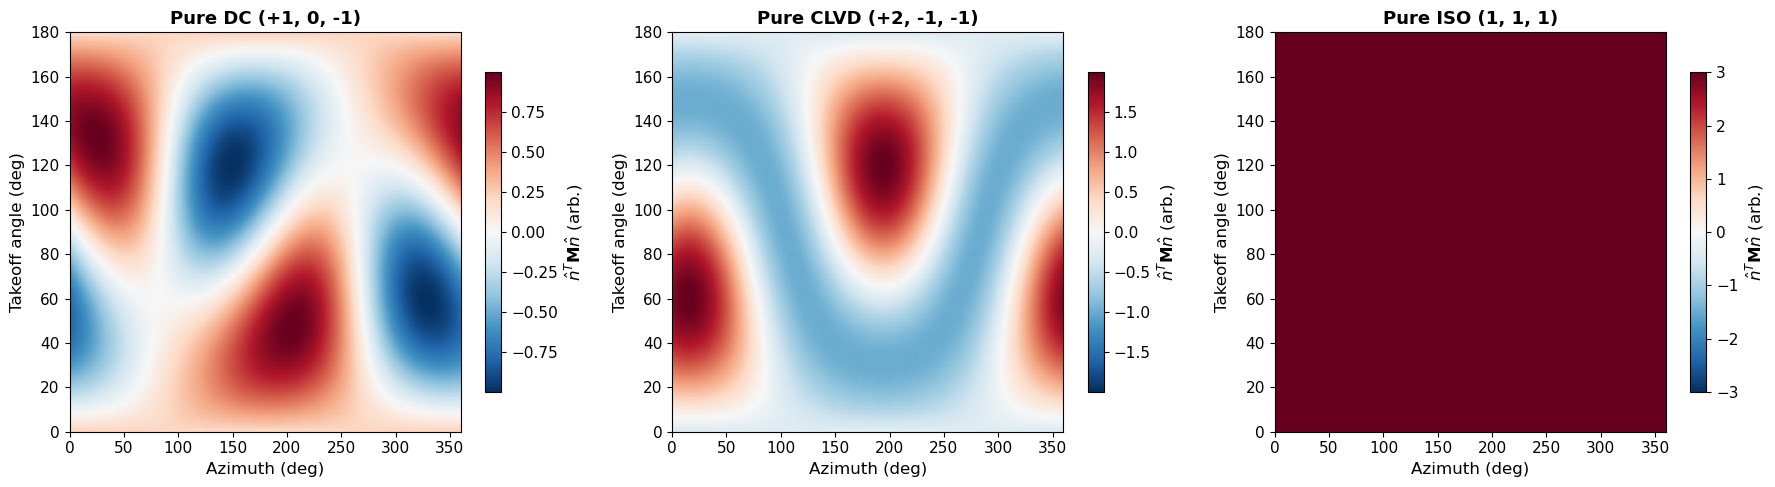

Key observations:
  DC:   Four-lobed pattern with two nodal planes (zero crossings)
  CLVD: Axially symmetric pattern with conical nodal surfaces
  ISO:  Uniform amplitude in ALL directions (no nodal planes)


In [8]:
def p_proxy(M, nhat):
    """Compute far-field P-wave radiation proxy: n^T M n"""
    nhat = np.asarray(nhat, dtype=float)
    nhat = nhat / np.linalg.norm(nhat)
    return nhat.T @ M @ nhat

def sample_sphere(n_theta=91, n_phi=181):
    """Sample unit vectors on a sphere for radiation pattern visualization."""
    thetas = np.linspace(0, np.pi, n_theta)
    phis = np.linspace(0, 2 * np.pi, n_phi)
    TH, PH = np.meshgrid(thetas, phis, indexing="ij")
    x = np.sin(TH) * np.cos(PH)
    y = np.sin(TH) * np.sin(PH)
    z = np.cos(TH)
    return TH, PH, x, y, z

def plot_p_proxy(M, title="P-wave radiation proxy", ax=None):
    """Plot P-wave radiation pattern on a theta-phi grid."""
    TH, PH, x, y, z = sample_sphere()
    A = np.zeros_like(x)
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            A[i, j] = p_proxy(M, [x[i, j], y[i, j], z[i, j]])

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))
    
    vmax = max(abs(A.min()), abs(A.max()))
    im = ax.imshow(A, aspect="auto", origin="lower",
                   extent=[0, 360, 0, 180], cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, label=r"$\hat{n}^T \mathbf{M} \hat{n}$ (arb.)", shrink=0.8)
    ax.set_xlabel("Azimuth (deg)", fontsize=12)
    ax.set_ylabel("Takeoff angle (deg)", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    return ax

# Compare three canonical source types
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_p_proxy(M_dc_pure, "Pure DC (+1, 0, -1)", ax=axes[0])
plot_p_proxy(M_clvd_pure, "Pure CLVD (+2, -1, -1)", ax=axes[1])
plot_p_proxy(M_iso_pure, "Pure ISO (1, 1, 1)", ax=axes[2])

plt.tight_layout()
plt.show()

print("Key observations:")
print("  DC:   Four-lobed pattern with two nodal planes (zero crossings)")
print("  CLVD: Axially symmetric pattern with conical nodal surfaces")
print("  ISO:  Uniform amplitude in ALL directions (no nodal planes)")

---

## Part E: Reading a USGS Moment Tensor

USGS event detail pages provide moment tensor components in the geographic (r, θ, φ) basis:
`tensor-mrr, tensor-mtt, tensor-mpp, tensor-mrt, tensor-mrp, tensor-mtp`

This section shows how to:
1. Fetch an event from USGS
2. Build the 3×3 tensor from these 6 components
3. Apply our decomposition
4. Compare with the catalog's reported %DC, %CLVD, %ISO

**Checklist for reading a catalog MT:**
1. **Scale:** $M_w$ / $M_0$
2. **ISO sign:** $\text{tr}(\mathbf{M}) > 0$ (explosive) or $< 0$ (implosive)
3. **DEV eigenvalues:** compute $\varphi_1 \geq \varphi_2 \geq \varphi_3$
4. **DC vs CLVD:** check $\varphi_2$ (or $\delta$)
5. **Orientation:** eigenvectors / P-T-N axes / nodal planes
6. **Interpretation:** match ISO/DC/CLVD content to a physical source model

> **Note:** This section requires internet access at runtime.

In [15]:
def fetch_usgs_event_geojson(event_id):
    """Fetch event detail GeoJSON from USGS FDSN earthquake API."""
    url = (
        "https://earthquake.usgs.gov/fdsnws/event/1/query"
        f"?eventid={event_id}&format=geojson"
    )
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return r.json()

def extract_usgs_moment_tensor(geojson):
    """
    Extract moment tensor components from USGS GeoJSON and build 3x3 matrix.
    
    Components are in the r-θ-φ (up, south, east) basis:
    mrr, mtt, mpp, mrt, mrp, mtp
    """
    products = geojson.get("properties", {}).get("products", {})
    mts = products.get("moment-tensor", [])
    if not mts:
        raise ValueError("No USGS moment-tensor product found for this event.")
    
    mt = mts[0]  # use first solution
    props = mt.get("properties", {})

    keys = ["tensor-mrr", "tensor-mtt", "tensor-mpp",
            "tensor-mrt", "tensor-mrp", "tensor-mtp"]
    if not all(k in props for k in keys):
        raise ValueError("Moment tensor components not found in expected fields.")
    
    mrr = float(props["tensor-mrr"])
    mtt = float(props["tensor-mtt"])
    mpp = float(props["tensor-mpp"])
    mrt = float(props["tensor-mrt"])
    mrp = float(props["tensor-mrp"])
    mtp = float(props["tensor-mtp"])

    # Assemble symmetric tensor in r-θ-φ basis
    M = np.array([[mrr, mrt, mrp],
                  [mrt, mtt, mtp],
                  [mrp, mtp, mpp]], dtype=float)
    return M, props

# --- Fetch and analyze a real earthquake ---
event_id = "us6000s94q"  # Change this to any USGS event ID with an MT solution

try:
    gj = fetch_usgs_event_geojson(event_id)
    M_usgs, props = extract_usgs_moment_tensor(gj)
    o = dc_clvd_decomposition(M_usgs)

    print(f"=== USGS Event: {gj['properties'].get('title')} ===")
    print(f"\nTensor (r, θ, φ basis):")
    print(M_usgs)
    
    print(f"\n--- Our Decomposition ---")
    print(f"tr(M)             = {np.trace(M_usgs):.4e}")
    print(f"DEV eigenvalues   = {o['eig_dev']}")
    print(f"δ                 = {o['delta']:.4f}")
    print(f"M0_dc             = {o['M0_dc']:.4e}")
    
    print(f"\n--- USGS Catalog Values ---")
    for k in ["percent-double-couple", "percent-clvd", "percent-isotropic"]:
        if k in props:
            print(f"  {k}: {props[k]}")
    
    print(f"\n--- Interpretation ---")
    if abs(o['delta']) < 0.1:
        print("→ Mostly double couple: consistent with tectonic shear faulting")
    elif abs(o['delta']) < 0.3:
        print("→ Moderate CLVD component: could be complex rupture or inversion artifact")
    else:
        print("→ Large CLVD component: may indicate non-shear source process")

except Exception as e:
    print(f"USGS fetch/parse failed: {repr(e)}")
    print("This cell requires internet access. You can try a different event_id.")

=== USGS Event: M 6.4 - 53 km WNW of Port-Olry, Vanuatu ===

Tensor (r, θ, φ basis):
[[ 1.6708e+18  1.8726e+18 -3.0485e+18]
 [ 1.8726e+18 -1.3481e+18  1.7241e+18]
 [-3.0485e+18  1.7241e+18 -3.2280e+17]]

--- Our Decomposition ---
tr(M)             = -1.0000e+14
DEV eigenvalues   = [ 3.9400e+18  5.7675e+17 -4.5168e+18]
δ                 = 0.1277
M0_dc             = 4.2284e+18

--- USGS Catalog Values ---
  percent-double-couple: 0.7446

--- Interpretation ---
→ Moderate CLVD component: could be complex rupture or inversion artifact


---

## Exercises

### 📝 Exercise 1 (ESS 412 - Undergraduate)

**Task:** Build a moment tensor that is **50% ISO + 50% DC** (you choose the scale). Then:
1. Compute $\text{tr}(\mathbf{M})$ and $\delta$
2. Run `dc_clvd_decomposition()` on your tensor
3. Verify that the ISO and DC parts match your construction
4. Interpret: what geophysical process might produce this combination?

In [10]:
# ===== YOUR CODE HERE =====
# Hint: A 50% ISO + 50% DC tensor could be constructed as:
#   M_dc_diag = np.diag([M0, 0, -M0])   for the DC part
#   M_iso = c * np.eye(3)                for the ISO part
#   M_total = M_dc + M_iso
# Choose M0 and c so that |M_iso| and |M_dc| are comparable.



# ===== END YOUR CODE =====

### 📝 Exercise 2 (ESS 412 - Undergraduate)

**Task:** Create **two different** moment tensors with the **same eigenvalues** but **different eigenvectors** (i.e., different orientations).

1. Use `make_tensor_from_diag([1.0, 0.0, -1.0])` twice (each call uses a random rotation)
2. Run `dc_clvd_decomposition()` on both
3. Compare: what is the same? What is different?
4. Plot the P-wave radiation proxy for both. What changes?
5. Explain: physically, what does changing eigenvectors correspond to?

In [11]:
# ===== YOUR CODE HERE =====
# Create two tensors with same eigenvalues but different orientations:
# M1 = make_tensor_from_diag([1.0, 0.0, -1.0])
# M2 = make_tensor_from_diag([1.0, 0.0, -1.0])
# 
# Decompose both and compare:
# o1 = dc_clvd_decomposition(M1)
# o2 = dc_clvd_decomposition(M2)
#
# Plot both radiation patterns:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# plot_p_proxy(M1, "DC orientation 1", ax=axes[0])
# plot_p_proxy(M2, "DC orientation 2", ax=axes[1])
# plt.tight_layout()
# plt.show()



# ===== END YOUR CODE =====

### 📝 Exercise 3 (ESS 512 - Graduate Only)

**Task:** Fetch a USGS earthquake of your choice, decompose it, and classify the source.

1. Go to [USGS Earthquake Catalog](https://earthquake.usgs.gov/earthquakes/search/) and find an event with a moment tensor solution. Copy the event ID (e.g., `us7000jg4q`).
2. Use `fetch_usgs_event_geojson()` and `extract_usgs_moment_tensor()` to get the tensor.
3. Run `dc_clvd_decomposition()` and report $\text{tr}(\mathbf{M})$, $\delta$, and $M_0^\text{DC}$.
4. Compare your computed δ with the USGS-reported `percent-double-couple` and `percent-clvd`.
5. Is the non-DC component (if any) physically meaningful, or likely an artifact? Justify your answer considering:
   - Station coverage (azimuthal gap)
   - Event depth and location
   - Tectonic setting
6. Plot the P-wave radiation proxy for the full tensor and for just the DC part. How different are they?

**Hint:** Try comparing a well-constrained tectonic event (high %DC) with a volcanic or induced seismicity event (potentially lower %DC).

In [12]:
# ===== GRADUATE EXERCISE 3 (ESS 512) =====
# Uncomment and implement:

# # Choose your event
# my_event_id = "..."  # paste USGS event ID here
# 
# gj = fetch_usgs_event_geojson(my_event_id)
# M_my, props_my = extract_usgs_moment_tensor(gj)
# o_my = dc_clvd_decomposition(M_my)
# 
# print(f"Event: {gj['properties'].get('title')}")
# print(f"tr(M) = {np.trace(M_my):.4e}")
# print(f"δ = {o_my['delta']:.4f}")
# print(f"M0_dc = {o_my['M0_dc']:.4e}")
# 
# # Compare radiation patterns: full tensor vs DC-only
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# plot_p_proxy(M_my, "Full MT", ax=axes[0])
# plot_p_proxy(o_my['M_dc'], "DC part only", ax=axes[1])
# plt.tight_layout()
# plt.show()

# ===== END GRADUATE EXERCISE =====

---

## Wrap-up: What you should be able to explain (verbally)

After completing this notebook, you should be able to answer:

**Conceptual:**
1. Why is the moment tensor symmetric, and how many independent components does it have?
2. What does the trace of the moment tensor tell you physically?
3. What eigenvalues define a pure double couple? A pure CLVD?
4. Why can't far-field P-wave data distinguish between the two nodal planes of a DC?
5. Name a geophysical process that would produce a significant ISO component.

**Mathematical:**
6. Write the ISO/DEV decomposition formulas.
7. Given DEV eigenvalues $\varphi_1, \varphi_2, \varphi_3$, compute $M_0^\text{DC}$ and $\delta$.
8. Why must $\varphi_1 + \varphi_2 + \varphi_3 = 0$ for the deviatoric part?

**Practical:**
9. Given a USGS MT with 80% DC and 20% CLVD, is the CLVD necessarily real?
10. How would you distinguish an explosion from an earthquake using moment tensors?

---

## Summary and Connections

### Key Takeaways

**The moment tensor is a compact source representation:**
- 6 independent components (symmetric 3×3 matrix)
- Diagonalization separates **orientation** (eigenvectors) from **source type** (eigenvalue ratios)

**Three-part decomposition reveals source physics:**
- **ISO** ($\text{tr}(\mathbf{M})$): volume change (explosion/implosion/opening)
- **DC** ($\varphi_2 = 0$): shear faulting (most tectonic earthquakes)
- **CLVD** ($\varphi_2 \neq 0$): complex deformation or inversion artifacts

**The δ diagnostic is your quick classifier:**
- $\delta = 0$ → pure DC (simple shear fault)
- $|\delta| = 0.5$ → pure CLVD
- Non-zero CLVD in tectonic events is often an artifact, not real physics

### Connections to Other Modules

**Module 3 (Ray Theory):**
- Takeoff angles determine which part of the radiation pattern each station samples
- Station distribution directly affects how well the MT can be constrained

**Module 5 (Surface Waves):**
- Long-period surface waves are the primary data for global MT inversion (GCMT catalog)
- Surface wave excitation depends on source depth and mechanism

**Module 6 (Earthquake Location):**
- Accurate locations are a prerequisite for moment tensor inversion
- Location errors propagate into mechanism errors
- The MT is estimated at the **centroid** (center of moment release), not the hypocenter

### Further Reading

- Shearer, P. M. (2009), *Introduction to Seismology*, 2nd ed., **Chapter 9.2**
- Jost, M. L., & Herrmann, R. B. (1989). A student's guide to and review of moment tensors. *Seismological Research Letters*, 60(2), 37–57.
- Tape, W., & Tape, C. (2012). A geometric setting for moment tensors. *Geophysical Journal International*, 190(1), 499–514.